# Week 08 · Image Segmentation & JPEG Standard
**Course:** Computer Vision (BCSE2022)
**Instructor:** Bùi Huy Kiên
**Prepared:** 2026-07-15


## 🎯 Mục tiêu học tập
Sau khi hoàn thành bài học này, sinh viên sẽ có thể:
- Phát hiện biên bằng gradient (Sobel) và thuật toán Canny; hiểu vai trò của làm mịn trước khi lấy đạo hàm.
- Phân ngưỡng toàn cục tự động bằng thuật toán Otsu; đọc histogram để đánh giá khả năng phân ngưỡng.
- Tách các đối tượng dính nhau bằng watershed dựa trên biến đổi khoảng cách (distance transform).
- Hiểu chuỗi xử lý JPEG: chia khối 8×8 → DCT → lượng tử hóa → giải nén; giải thích blocking artifact.
- Đánh giá chất lượng nén bằng PSNR và quan hệ chất lượng ↔ tỷ lệ nén.


**Hướng dẫn:**
- Ảnh mẫu lấy từ bộ ảnh sách Gonzalez & Woods (DIP 3rd ed.) trong thư mục `Gonzalez_images/` ở gốc repo.
- Mỗi cell hiển thị ảnh dùng `matplotlib`.
- Sử dụng các thư viện: `opencv-python`, `numpy`, `matplotlib`.
- Nếu được, khuyến khích xây dựng lại các thuật toán sử dụng C++/Python


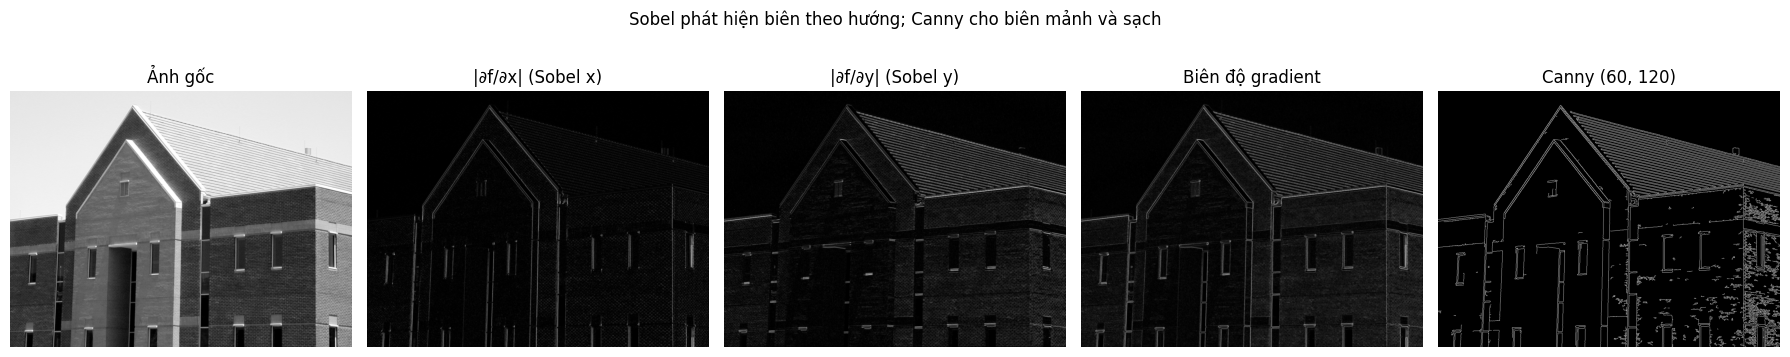

In [1]:
## Ví dụ 1: Phát hiện biên — Sobel và Canny
# - Sobel: xấp xỉ đạo hàm bậc nhất theo x, y; biên = căn bậc hai tổng bình phương.
# - Canny: làm mịn Gaussian + gradient + non-maximum suppression + hysteresis
#   -> biên mảnh 1 pixel, ít nhiễu hơn nhiều.

import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

img = np.asarray(Image.open("../../Gonzalez_images/DIP3E_Original_Images_CH10/Fig1016(a)(building_original).tif").convert("L"))

gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
grad = np.sqrt(gx**2 + gy**2)
grad = (grad / grad.max() * 255)

edges_canny = cv2.Canny(cv2.GaussianBlur(img, (5, 5), 0), 60, 120)

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, (t, im) in zip(axes, [("Ảnh gốc", img), ("|∂f/∂x| (Sobel x)", np.abs(gx)),
                              ("|∂f/∂y| (Sobel y)", np.abs(gy)),
                              ("Biên độ gradient", grad), ("Canny (60, 120)", edges_canny)]):
    ax.imshow(im, cmap="gray")
    ax.set_title(t); ax.axis("off")
plt.suptitle("Sobel phát hiện biên theo hướng; Canny cho biên mảnh và sạch")
plt.tight_layout()
plt.show()


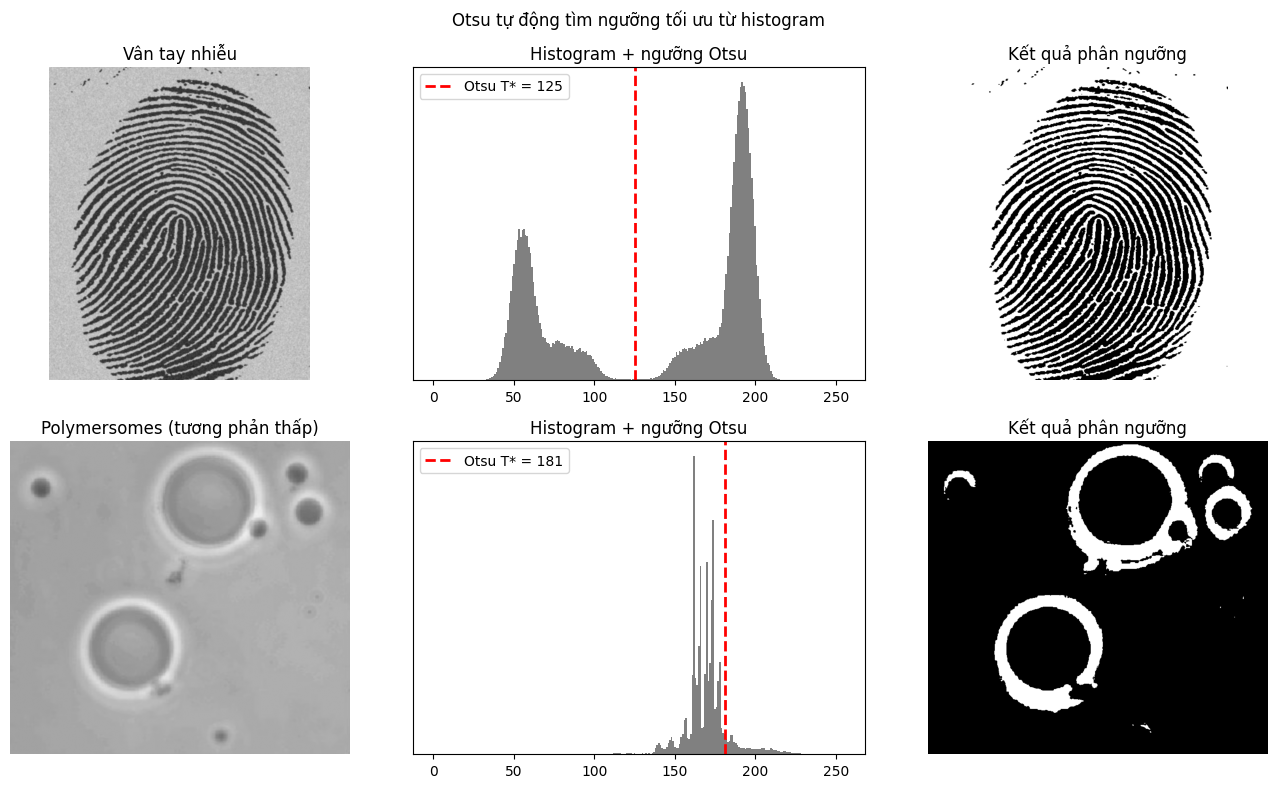

In [2]:
## Ví dụ 2: Phân ngưỡng toàn cục tự động — thuật toán Otsu
# Otsu chọn ngưỡng T* cực đại hóa phương sai GIỮA hai lớp trên histogram.
# Hoạt động tốt khi histogram có 2 đỉnh tách biệt (bimodal).

import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

files = [("../../Gonzalez_images/DIP3E_Original_Images_CH10/Fig1038(a)(noisy_fingerprint).tif", "Vân tay nhiễu"),
         ("../../Gonzalez_images/DIP3E_Original_Images_CH10/Fig1039(a)(polymersomes).tif", "Polymersomes (tương phản thấp)")]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for row, (path, name) in enumerate(files):
    img = np.asarray(Image.open(path).convert("L"))
    T, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    axes[row, 0].imshow(img, cmap="gray", vmin=0, vmax=255)
    axes[row, 0].set_title(f"{name}"); axes[row, 0].axis("off")
    axes[row, 1].hist(img.ravel(), bins=256, range=(0, 255), color="gray")
    axes[row, 1].axvline(T, color="red", ls="--", lw=2, label=f"Otsu T* = {T:.0f}")
    axes[row, 1].set_title("Histogram + ngưỡng Otsu"); axes[row, 1].legend(); axes[row, 1].set_yticks([])
    axes[row, 2].imshow(binary, cmap="gray")
    axes[row, 2].set_title("Kết quả phân ngưỡng"); axes[row, 2].axis("off")
plt.suptitle("Otsu tự động tìm ngưỡng tối ưu từ histogram")
plt.tight_layout()
plt.show()


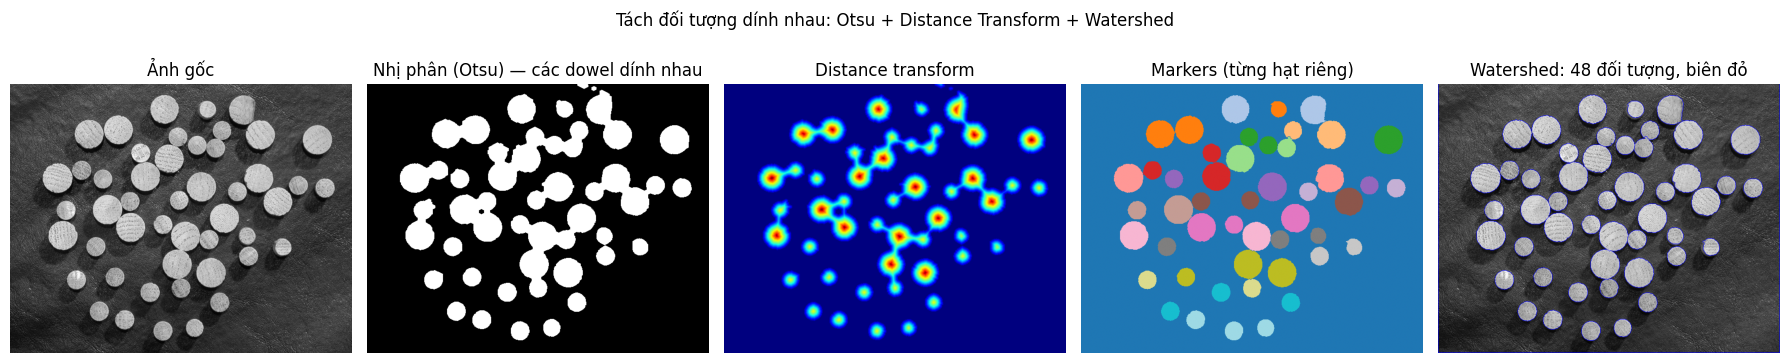

In [3]:
## Ví dụ 3: Watershed — tách các đối tượng dính nhau
# Các thanh gỗ tròn chạm nhau -> phân ngưỡng thường cho MỘT khối dính.
# Distance transform + watershed "chia nước" tại chỗ thắt giữa hai đối tượng.

import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

img = np.asarray(Image.open("../../Gonzalez_images/DIP3E_Original_Images_CH09/Fig0941(a)(wood_dowels).tif").convert("L"))

# 1) Nhị phân hóa (Otsu) + đóng để lấp lỗ texture + mở để khử nhiễu nhỏ
_, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, se, iterations=2)
binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, se, iterations=2)

# 2) Vùng chắc chắn là nền / đối tượng
sure_bg = cv2.dilate(binary, se, iterations=3)
dist = cv2.distanceTransform(binary, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist, 0.5 * dist.max(), 255, 0)
sure_fg = sure_fg.astype(np.uint8)
unknown = cv2.subtract(sure_bg, sure_fg)

# 3) Đánh nhãn marker và chạy watershed
n_markers, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0
img_bgr = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
markers = cv2.watershed(img_bgr, markers)

# Tô màu kết quả, biên watershed = đỏ
result = img_bgr.copy()
result[markers == -1] = [255, 0, 0]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, (t, im, kw) in zip(axes, [
        ("Ảnh gốc", img, dict(cmap="gray")),
        ("Nhị phân (Otsu) — các dowel dính nhau", binary, dict(cmap="gray")),
        ("Distance transform", dist, dict(cmap="jet")),
        ("Markers (từng hạt riêng)", markers, dict(cmap="tab20")),
        (f"Watershed: {n_markers - 1} đối tượng, biên đỏ", result[..., ::-1], dict())]):
    ax.imshow(im, **kw)
    ax.set_title(t); ax.axis("off")
plt.suptitle("Tách đối tượng dính nhau: Otsu + Distance Transform + Watershed")
plt.tight_layout()
plt.show()


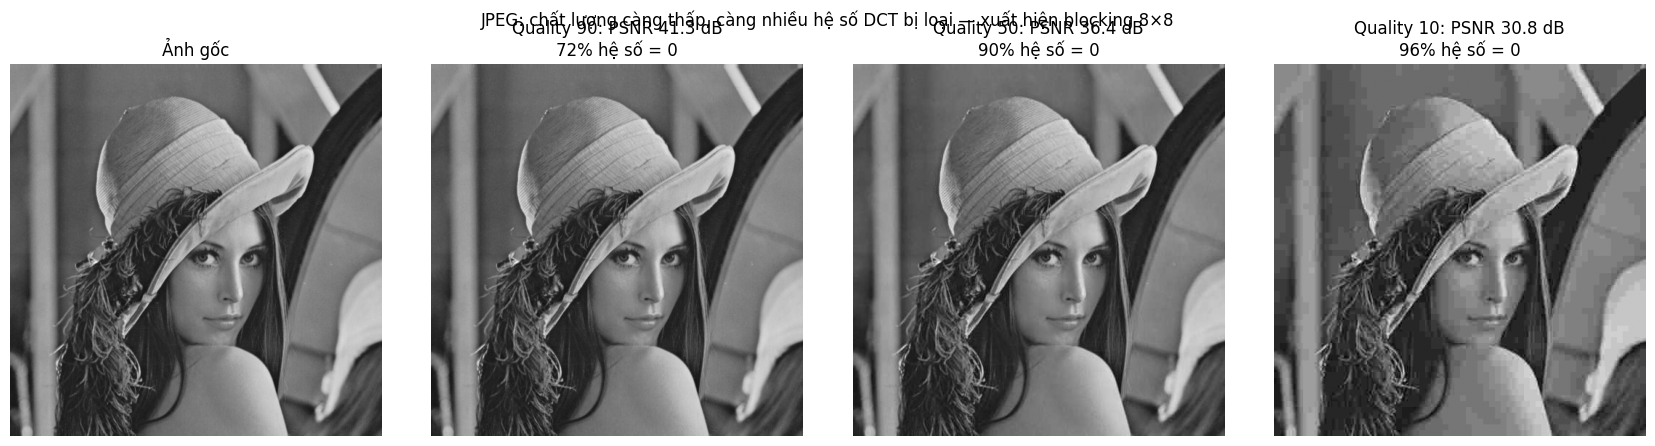

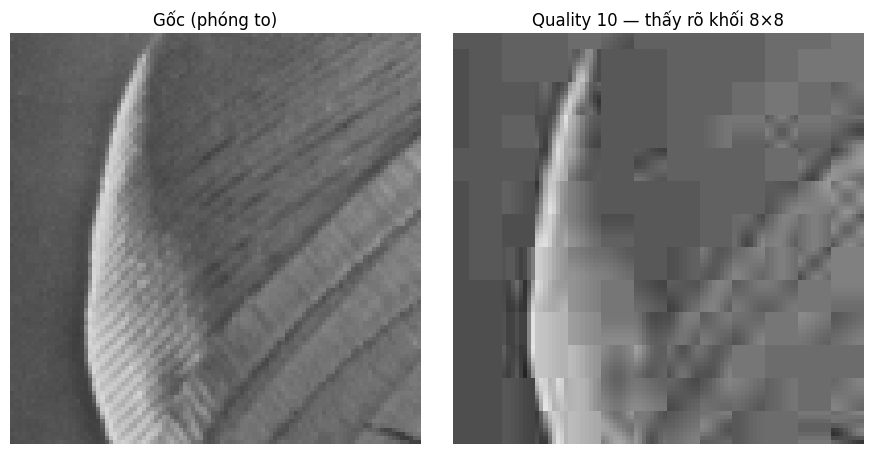

In [4]:
## Ví dụ 4: "JPEG thu nhỏ" — DCT khối 8×8 và lượng tử hóa
# Chuỗi JPEG (thành phần chói): chia khối 8×8 -> DCT -> chia cho ma trận lượng tử hóa
# -> làm tròn (MẤT thông tin ở đây!) -> giải nén ngược lại.
# Hệ số chất lượng thấp -> nhiều hệ số bị làm tròn về 0 -> blocking artifact.

import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

img = np.asarray(Image.open("../../Gonzalez_images/DIP3E_CH08_Original_Images/Fig0809(a).tif").convert("L")).astype(np.float64)
h, w = img.shape
h8, w8 = h // 8 * 8, w // 8 * 8
img = img[:h8, :w8]

# Ma trận lượng tử hóa chuẩn JPEG (luminance)
Q50 = np.array([
    [16, 11, 10, 16, 24, 40, 51, 61],
    [12, 12, 14, 19, 26, 58, 60, 55],
    [14, 13, 16, 24, 40, 57, 69, 56],
    [14, 17, 22, 29, 51, 87, 80, 62],
    [18, 22, 37, 56, 68,109,103, 77],
    [24, 35, 55, 64, 81,104,113, 92],
    [49, 64, 78, 87,103,121,120,101],
    [72, 92, 95, 98,112,100,103, 99]], dtype=np.float64)

def q_matrix(quality):
    """Suy ma trận lượng tử hóa từ hệ số chất lượng 1..100 (chuẩn IJG)."""
    s = 5000 / quality if quality < 50 else 200 - 2 * quality
    Q = np.floor((Q50 * s + 50) / 100)
    return np.clip(Q, 1, 255)

def jpeg_roundtrip(img, quality):
    """Nén + giải nén từng khối 8×8, trả về ảnh tái tạo và tỷ lệ hệ số = 0."""
    Q = q_matrix(quality)
    out = np.zeros_like(img)
    zeros, total = 0, 0
    for i in range(0, img.shape[0], 8):
        for j in range(0, img.shape[1], 8):
            block = img[i:i+8, j:j+8] - 128          # dịch mức về [-128,127]
            coefs = cv2.dct(block)
            quant = np.round(coefs / Q)              # <-- bước MẤT thông tin
            zeros += np.sum(quant == 0); total += 64
            out[i:i+8, j:j+8] = cv2.idct(quant * Q) + 128
    return np.clip(out, 0, 255), zeros / total

qualities = [90, 50, 10]
fig, axes = plt.subplots(1, len(qualities) + 1, figsize=(17, 4.5))
axes[0].imshow(img, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Ảnh gốc"); axes[0].axis("off")
for ax, q in zip(axes[1:], qualities):
    rec, zfrac = jpeg_roundtrip(img, q)
    psnr = cv2.PSNR(img.astype(np.uint8), rec.astype(np.uint8))
    ax.imshow(rec, cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"Quality {q}: PSNR {psnr:.1f} dB\n{zfrac*100:.0f}% hệ số = 0")
    ax.axis("off")
plt.suptitle("JPEG: chất lượng càng thấp, càng nhiều hệ số DCT bị loại — xuất hiện blocking 8×8")
plt.tight_layout()
plt.show()

# Phóng to một vùng để thấy blocking artifact
rec10, _ = jpeg_roundtrip(img, 10)
crop = (slice(100, 200), slice(100, 200))
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].imshow(img[crop], cmap="gray", vmin=0, vmax=255); axes[0].set_title("Gốc (phóng to)")
axes[1].imshow(rec10[crop], cmap="gray", vmin=0, vmax=255); axes[1].set_title("Quality 10 — thấy rõ khối 8×8")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()


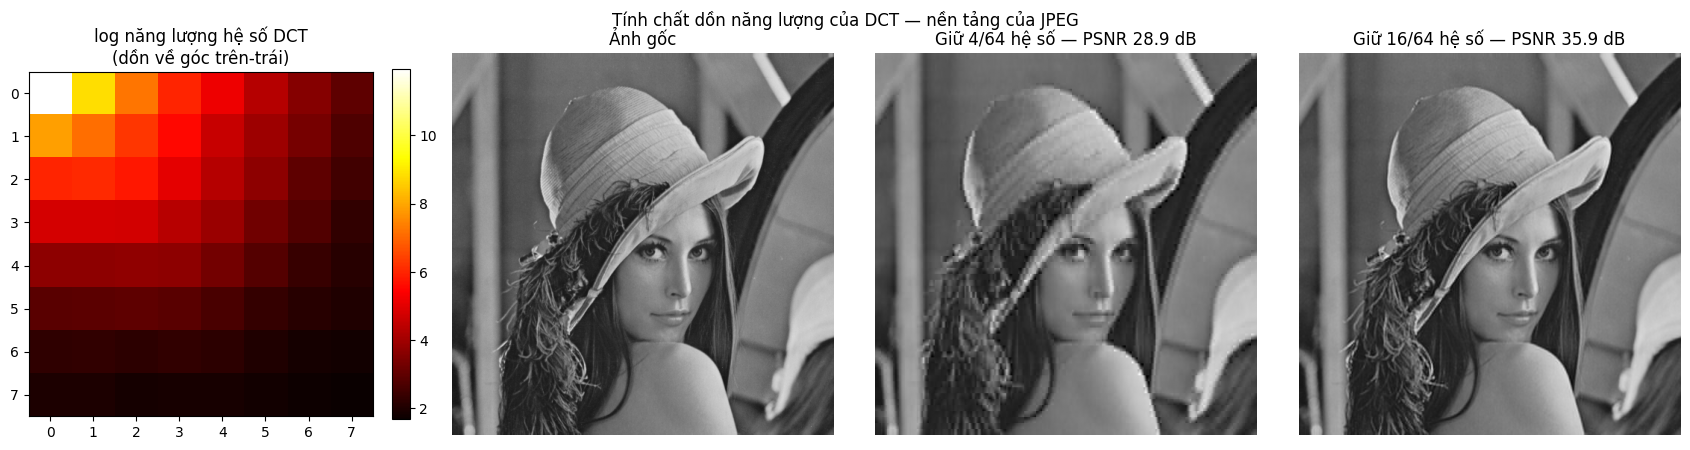

In [5]:
## Ví dụ 5: Năng lượng hệ số DCT — vì sao JPEG hiệu quả
# DCT dồn năng lượng của khối ảnh về góc trên-trái (tần số thấp).
# Chỉ giữ vài hệ số đầu theo đường zigzag là đủ tái tạo gần đúng khối ảnh.

import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

img = np.asarray(Image.open("../../Gonzalez_images/DIP3E_CH08_Original_Images/Fig0809(a).tif").convert("L")).astype(np.float64)
h8, w8 = img.shape[0] // 8 * 8, img.shape[1] // 8 * 8
img = img[:h8, :w8]

# Năng lượng trung bình của từng vị trí hệ số DCT trên toàn ảnh
energy = np.zeros((8, 8))
for i in range(0, h8, 8):
    for j in range(0, w8, 8):
        energy += cv2.dct(img[i:i+8, j:j+8] - 128) ** 2
energy /= (h8 // 8) * (w8 // 8)

# Giữ k hệ số đầu (theo thứ tự năng lượng giảm dần) và tái tạo
order = np.argsort(energy.ravel())[::-1]
def keep_k(img, k):
    mask = np.zeros(64); mask[order[:k]] = 1
    mask = mask.reshape(8, 8)
    out = np.zeros_like(img)
    for i in range(0, img.shape[0], 8):
        for j in range(0, img.shape[1], 8):
            out[i:i+8, j:j+8] = cv2.idct(cv2.dct(img[i:i+8, j:j+8] - 128) * mask) + 128
    return np.clip(out, 0, 255)

fig = plt.figure(figsize=(17, 4.5))
ax = fig.add_subplot(1, 4, 1)
im = ax.imshow(np.log1p(energy), cmap="hot")
ax.set_title("log năng lượng hệ số DCT\n(dồn về góc trên-trái)")
plt.colorbar(im, ax=ax, fraction=0.046)
for idx, k in enumerate([4, 16], start=2):
    rec = keep_k(img, k)
    psnr = cv2.PSNR(img.astype(np.uint8), rec.astype(np.uint8))
    ax = fig.add_subplot(1, 4, idx + 1)
    ax.imshow(rec, cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"Giữ {k}/64 hệ số — PSNR {psnr:.1f} dB"); ax.axis("off")
ax = fig.add_subplot(1, 4, 2)
ax.imshow(img, cmap="gray", vmin=0, vmax=255); ax.set_title("Ảnh gốc"); ax.axis("off")
plt.suptitle("Tính chất dồn năng lượng của DCT — nền tảng của JPEG")
plt.tight_layout()
plt.show()


## 📝 Exercises (en)
1. Tune Canny thresholds on `Fig1034(a)(marion_airport).tif` (CH10) to extract the runways as cleanly as possible. Report your (low, high) values.
2. Otsu fails on `Fig1046(a)(septagon_noisy_shaded).tif` (shaded background). Implement **block-wise Otsu** (split the image into 6 tiles, threshold each) and compare with global Otsu.
3. Apply the watershed pipeline of Example 3 to `Fig1043(a)(yeast_USC).tif` (CH10). How many cells are detected? What fails and why?
4. In Example 4, plot PSNR versus quality ∈ {5, 10, 20, …, 90} and the fraction of zero coefficients on a second axis. Where is the "knee" of the curve?
5. (Optional) Implement the zigzag scan and run-length coding of quantized DCT coefficients to estimate the actual compressed size (bits) of each quality level.

## 📝 Bài tập (vi)
1. Chỉnh ngưỡng Canny trên `Fig1034(a)(marion_airport).tif` (CH10) để tách đường băng rõ nhất có thể. Báo cáo cặp ngưỡng (thấp, cao) đã chọn.
2. Otsu thất bại trên `Fig1046(a)(septagon_noisy_shaded).tif` (nền bị đổ bóng). Cài đặt **Otsu theo khối** (chia ảnh thành 6 ô, phân ngưỡng từng ô) và so sánh với Otsu toàn cục.
3. Áp dụng chuỗi watershed ở Ví dụ 3 cho `Fig1043(a)(yeast_USC).tif` (CH10). Phát hiện được bao nhiêu tế bào? Trường hợp nào thất bại và vì sao?
4. Ở Ví dụ 4, vẽ đồ thị PSNR theo quality ∈ {5, 10, 20, …, 90} và tỷ lệ hệ số bằng 0 trên trục thứ hai. "Điểm gãy" của đường cong nằm ở đâu?
5. (Tuỳ chọn) Cài đặt quét zigzag và mã hóa run-length cho hệ số DCT đã lượng tử hóa để ước lượng kích thước nén thực tế (bit) ở từng mức quality.